# ===============================
# FEATURE ENGINEERING NOTEBOOK
# ===============================

## Objectives

- Engineer features for regression modeling (SalePrice)
- Encode categorical variables, transform numeric features if necessary
- Reduce variables using correlation-based selection
- Generate a clean dataset ready for model training


## Inputs
* Cleaned dataset: 
    - `outputs/datasets/cleaned/CleanedData.csv`

## Outputs
- Transformed TrainSet and TestSet
- List of applied transformers:
    - Ordinal categorical encoding
    - Log/Power/Box-Cox transformations
    - Winsorization (IQR)
    - Smart correlation selection


### Import Cell

In [127]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from feature_engine.encoding import OrdinalEncoder
from feature_engine.outliers import Winsorizer
from pathlib import Path

sns.set(style="whitegrid")

---

## Change working directory

We need to set the current working directory to the parent folder for consistency.

In [128]:
# Check current directory
current_dir = os.getcwd()
print("Current directory:", current_dir)

# Move to parent directory
os.chdir(os.path.dirname(current_dir))
print("New current directory:", os.getcwd())

Current directory: c:\
New current directory: c:\


Confirm the new current directory

In [129]:
current_dir = os.getcwd()
current_dir

'c:\\'

## Load Cleaned Data

We load the cleaned dataset and split it into Train and Test sets.



In [ ]:
from sklearn.model_selection import train_test_split

BASE_DIR = Path(r"C:\Users\david\Portfolio 5\heritage-housing")
data_path = BASE_DIR / "outputs/datasets/cleaned/CleanedData.csv"

# Load data
df = pd.read_csv(data_path)

# Split into Train and Test sets
TrainSet, TestSet = train_test_split(df, test_size=0.2, random_state=42)

print("TrainSet shape:", TrainSet.shape)
print("TestSet shape:", TestSet.shape)

TrainSet shape: (1168, 22)
TestSet shape: (292, 22)


---

## Helper Functions

These functions help check missing values and generate diagnostic plots for numeric and categorical features.

In [131]:
# Check missing values
def check_missing_values(df):
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print("* No missing values found.")
    else:
        print("* Missing values found:")
        print(missing)

# Numeric diagnostic plots
def diagnostic_plots(df, col):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=axes[0])
    stats.probplot(df[col], dist="norm", plot=axes[1])
    sns.boxplot(x=df[col], ax=axes[2])
    axes[0].set_title("Histogram")
    axes[1].set_title("QQ Plot")
    axes[2].set_title("Boxplot")
    fig.suptitle(col, fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

# Categorical diagnostic plots
def diagnostic_plots_cat(df, col):
    plt.figure(figsize=(4,3))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(col)
    plt.xticks(rotation=90)
    plt.show()

# ===============================
## Phase 1: Exploration (Analysis only)
# ===============================

## Identity Variables for Feature Engineering

### Ordinal Categorical Variables

- `KitchenQual`, `ExterQual`, `ExterCond`, `BsmtQual`, `BsmtCond`, `GarageQual`, `GarageCond`, `FireplaceQu`  
These features have a natural order, so we will encode them numerically.

### Numeric Variables for Transformation:**  
- `GrLivArea`, `LotArea`, `TotalBsmtSF`, `1stFlrSF`, `BsmtFinSF1`  
These features are right-skewed or have outliers and could potentially benefit from log/power/Box-Cox transformations.

### Variables for Correlation-Based Reduction:
- All numeric features  
To reduce multicollinearity and  thus keep only the most informative features.

---

# ===============================
## Phase 2: Final Pipeline (Model Ready)
# ===============================

## Apply Feature Engineering Transformers

### Ordinal Categorical Encoding 
We encode ordinal categorical variables to numeric values.

In [ ]:
# Select variables
ordinal_vars = ['KitchenQual', 'BsmtExposure', 'BsmtFinType1', 'GarageFinish']

# Create engineering DataFrame
df_engineering = TrainSet[ordinal_vars].copy()
df_engineering.head(3)

# Check missing values
check_missing_values(df_engineering)

# Apply encoder to Train and Test
encoder = OrdinalEncoder(
    encoding_method="arbitrary",
    variables=ordinal_vars,
    missing_values="ignore"
)

TrainSet = encoder.fit_transform(TrainSet)
TestSet = encoder.transform(TestSet)

print("* Ordinal categorical encoding done!")
TrainSet[ordinal_vars].head()

* Missing values found:
BsmtExposure     28
BsmtFinType1    116
GarageFinish    186
dtype: int64
* Ordinal categorical encoding done!


c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\feature_engine\encoding\base_encoder.py:260: UserWarning: During the encoding, NaN values were introduced in the feature(s) BsmtExposure, BsmtFinType1, GarageFinish.
  warnings.warn(
c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\feature_engine\encoding\base_encoder.py:260: UserWarning: During the encoding, NaN values were introduced in the feature(s) BsmtExposure, BsmtFinType1, GarageFinish.
  warnings.warn(


,KitchenQual,BsmtExposure,BsmtFinType1,GarageFinish
254,0,0.0,0.0,0.0
1066,0,0.0,1.0,0.0
638,0,0.0,1.0,NaN
799,1,0.0,2.0,1.0
380,1,0.0,3.0,1.0


### Numerical Transformations 
- We apply log transformations to reduce skewness of numeric features.
- Reduce skewness for numeric features that strongly influence `SalePrice`
- Apply multiple log transformations to the most important features identified in the EDA Analysis.
    - These features are likely to benefit the most from a log transformation due to being right skewed: `GrLivArea`, `LotArea`, `TotalBsmtSF`, `1stFlrSF`, `BsmtFinSF1` 

#### Create Diagnostic Plots and Generate Log Transformed Features 

* No missing values found.

Variable: GrLivArea


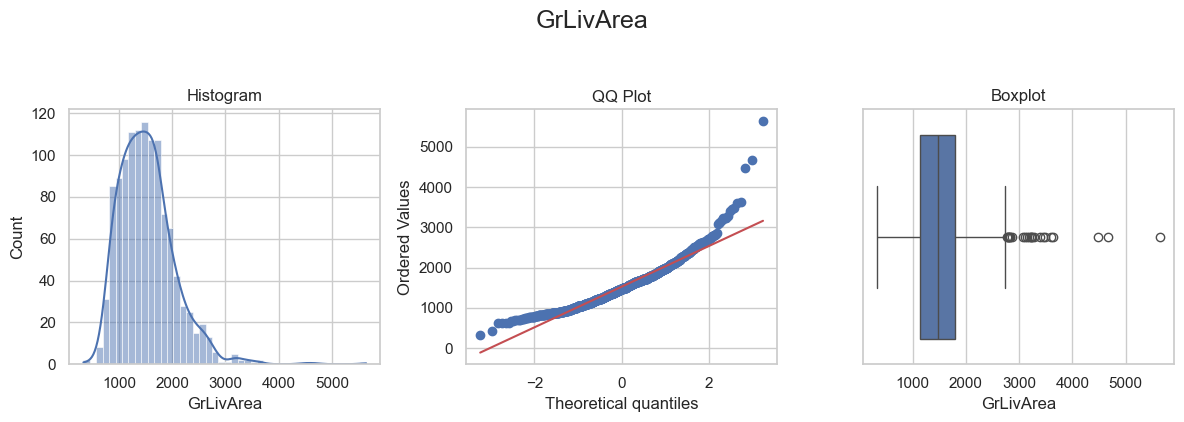

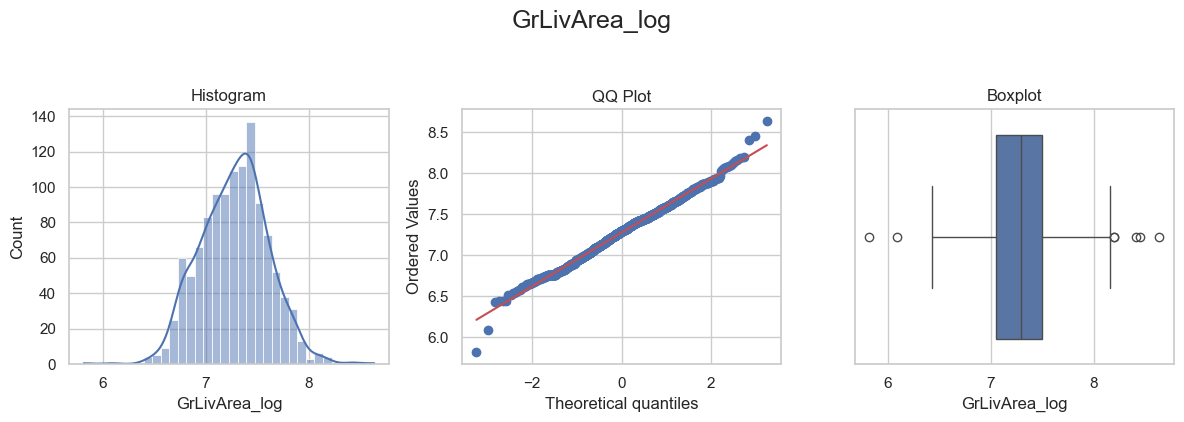

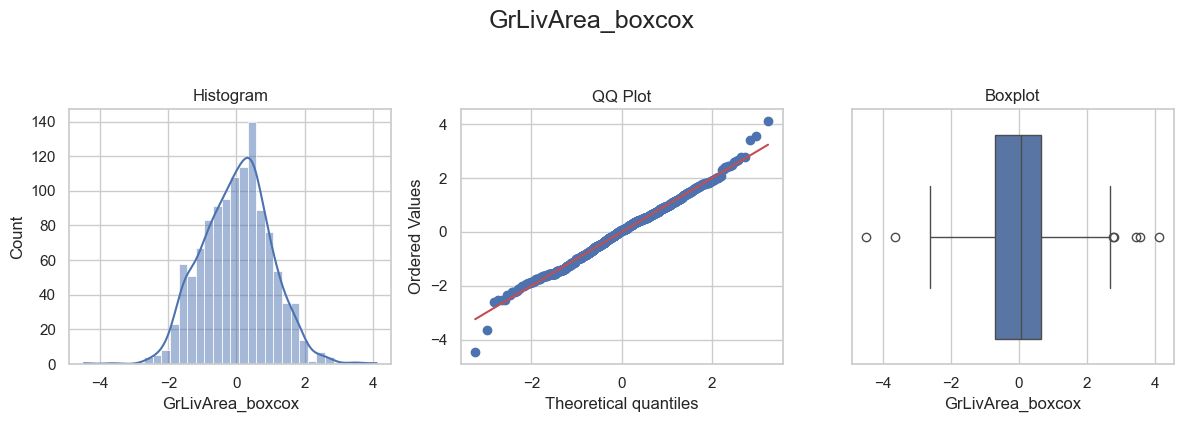

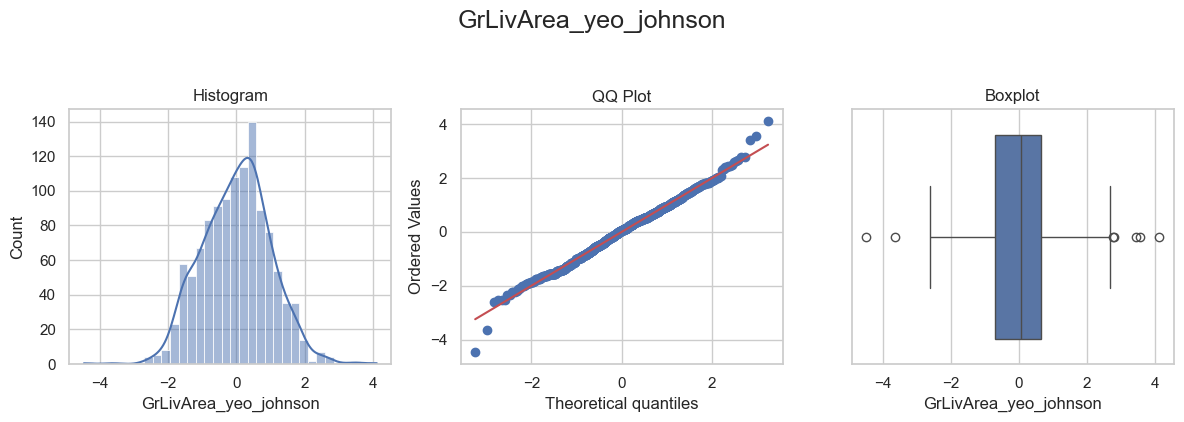


Variable: LotArea


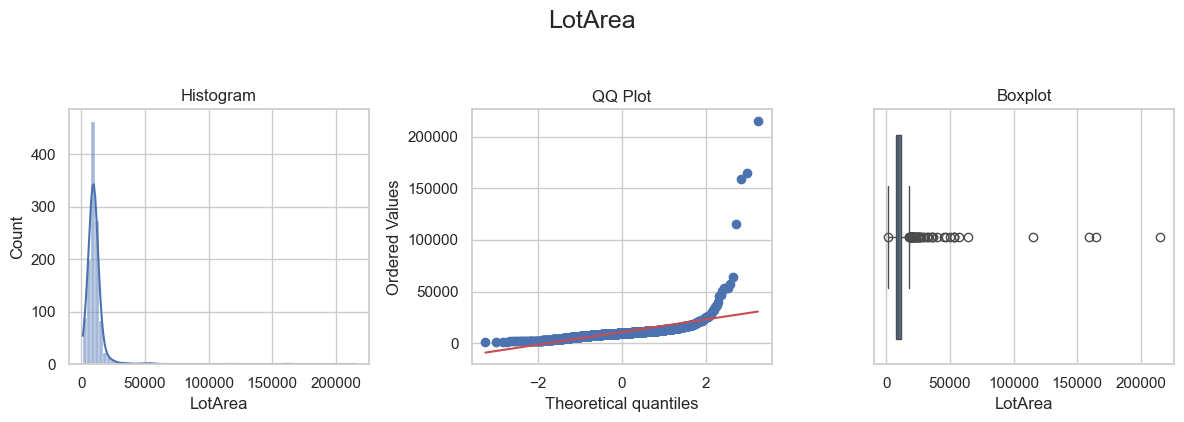

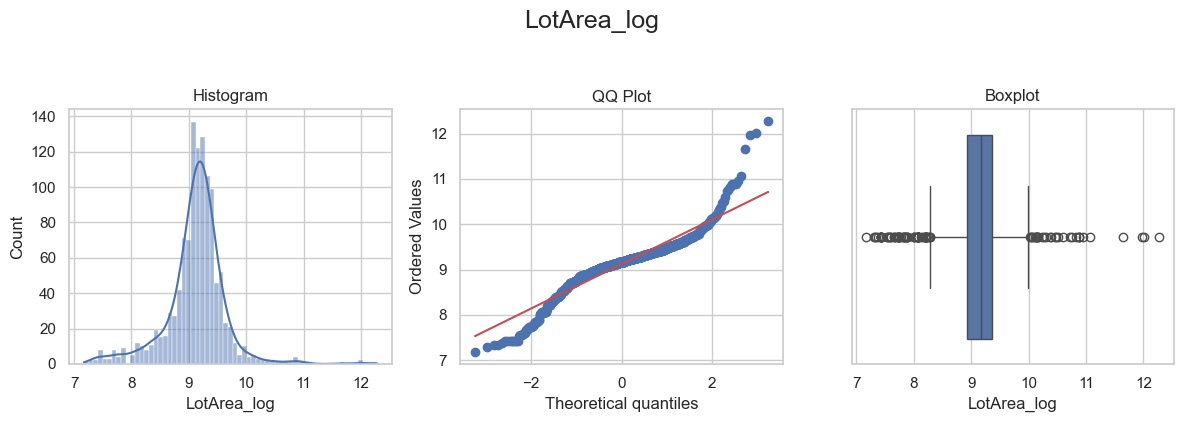

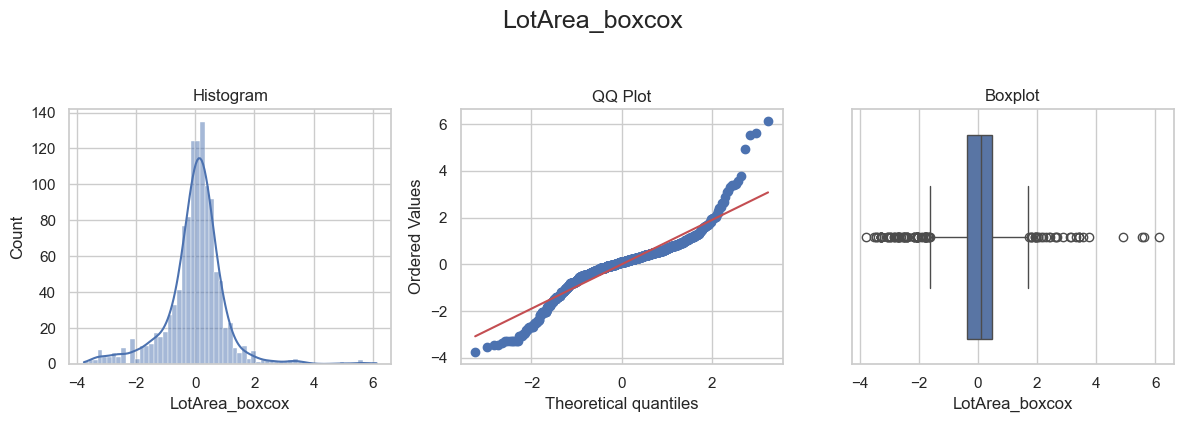

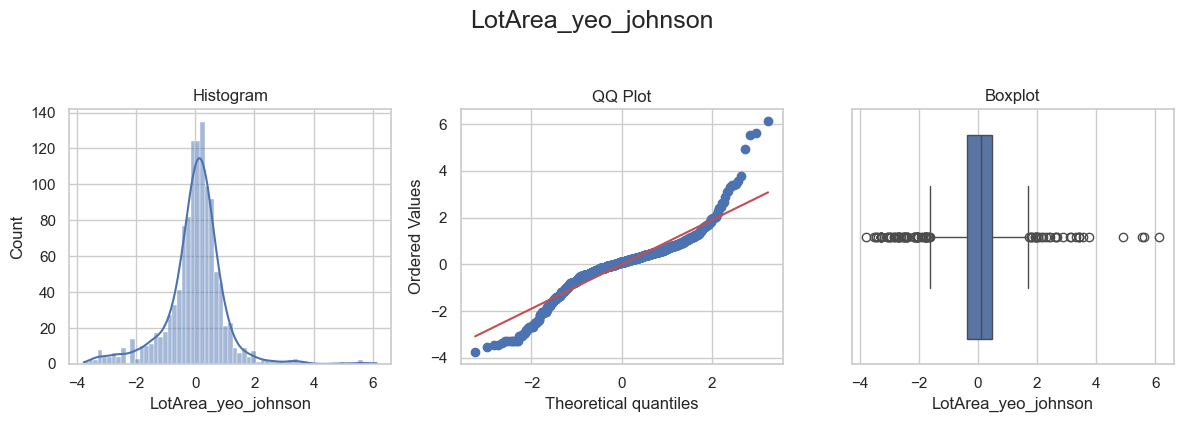

* Skipping Box-Cox for TotalBsmtSF (non-positive values present)

Variable: TotalBsmtSF


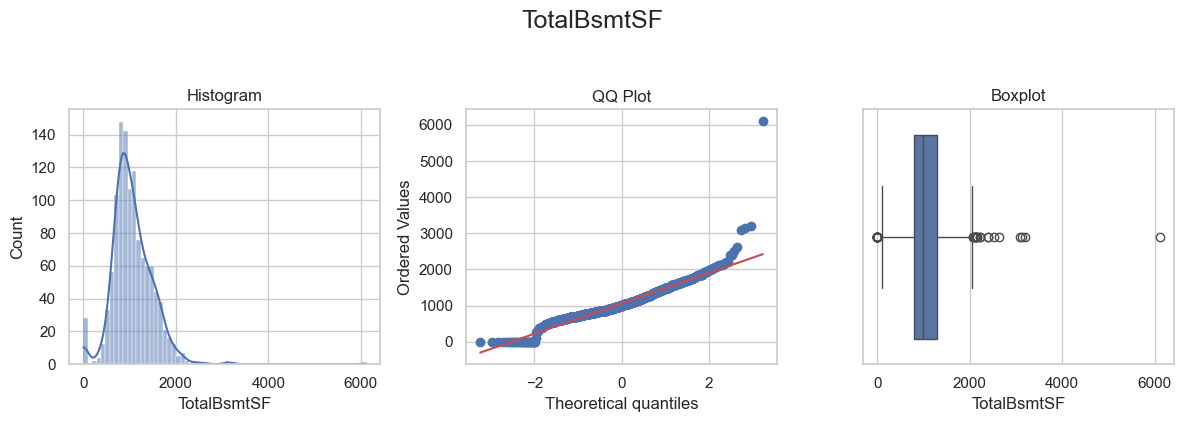

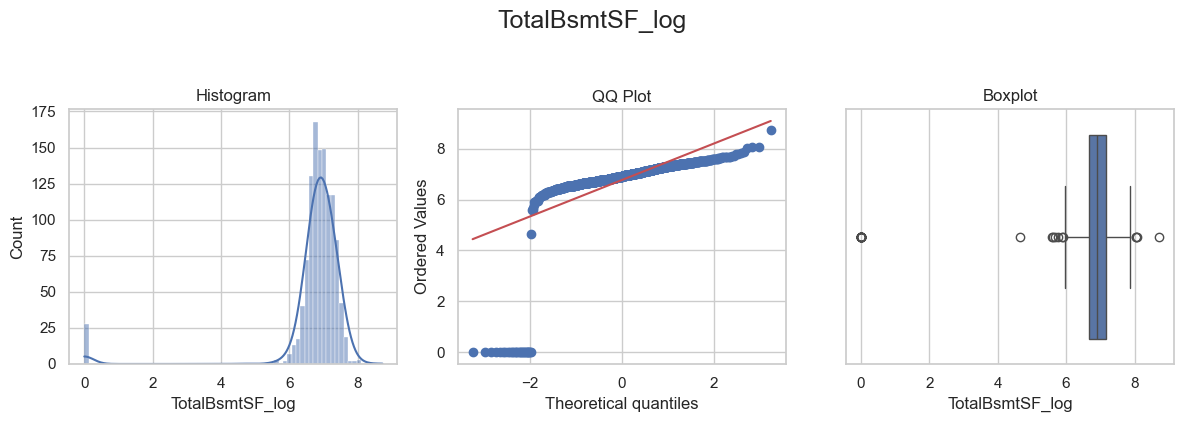

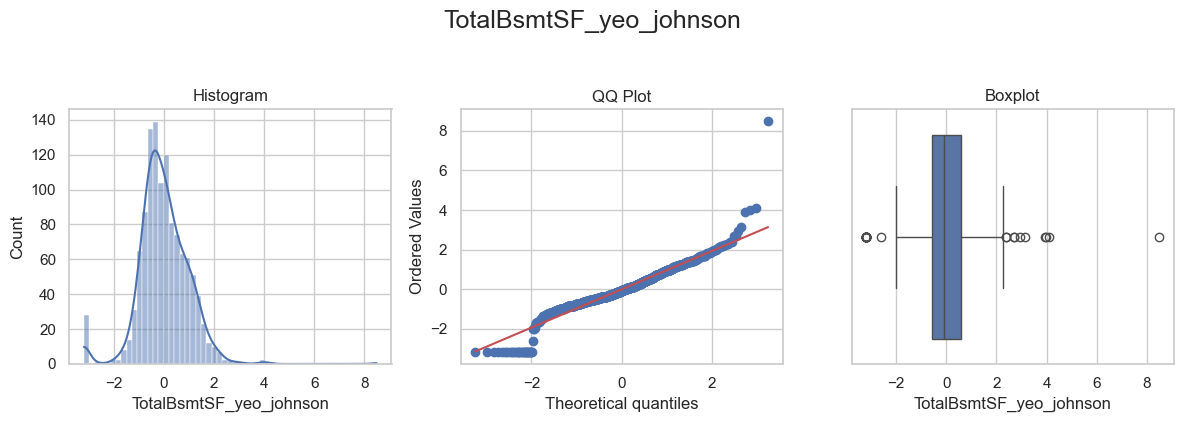


Variable: 1stFlrSF


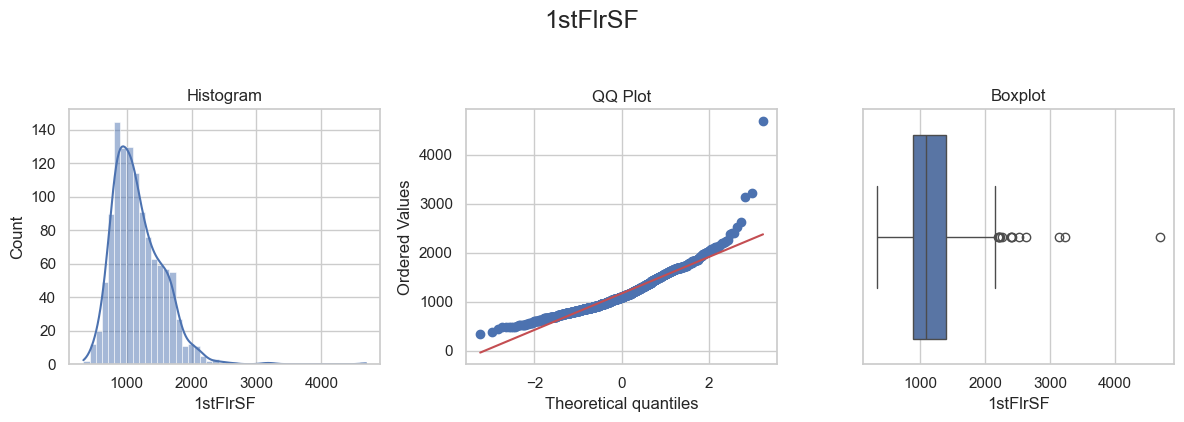

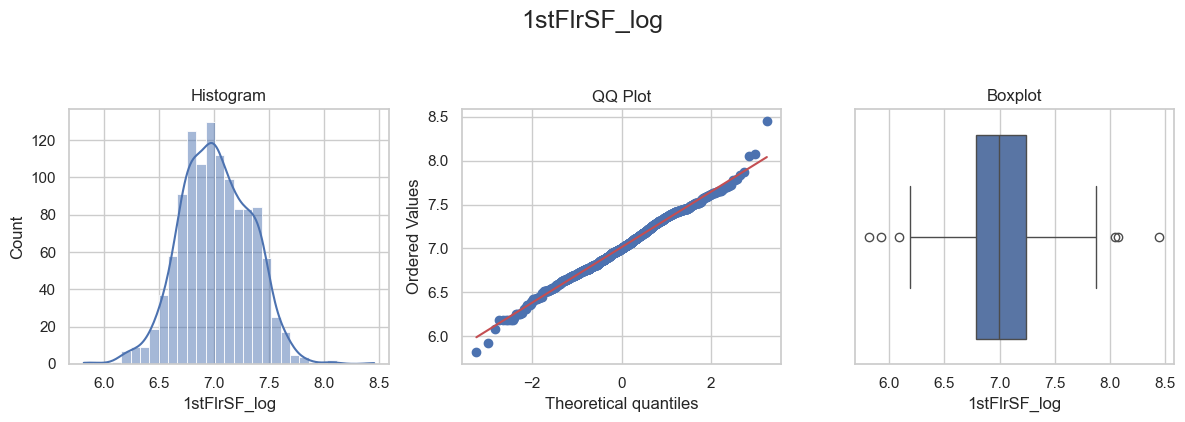

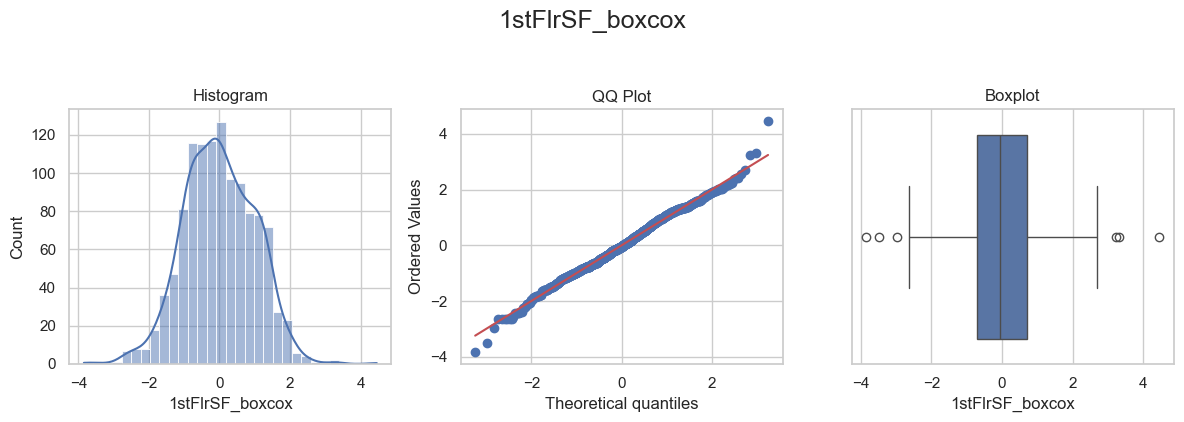

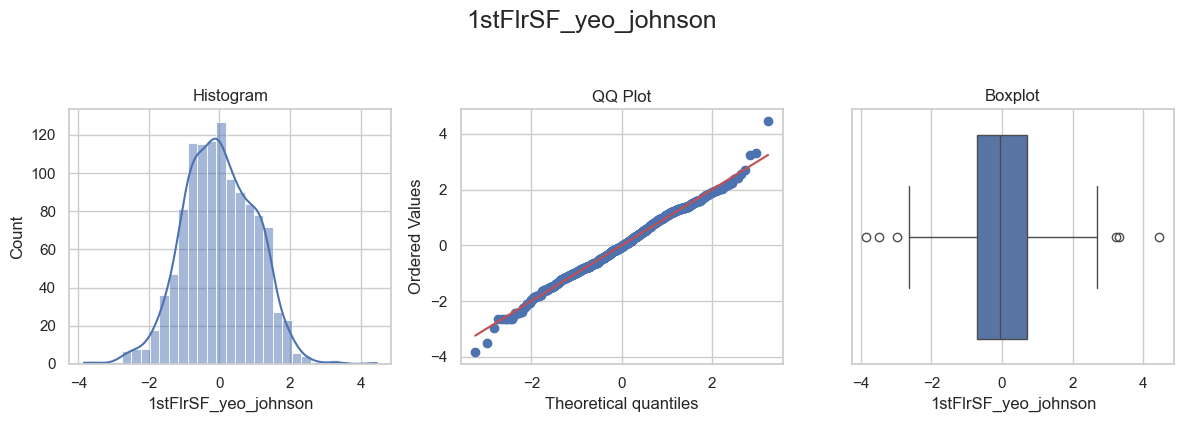

* Skipping Box-Cox for BsmtFinSF1 (non-positive values present)

Variable: BsmtFinSF1


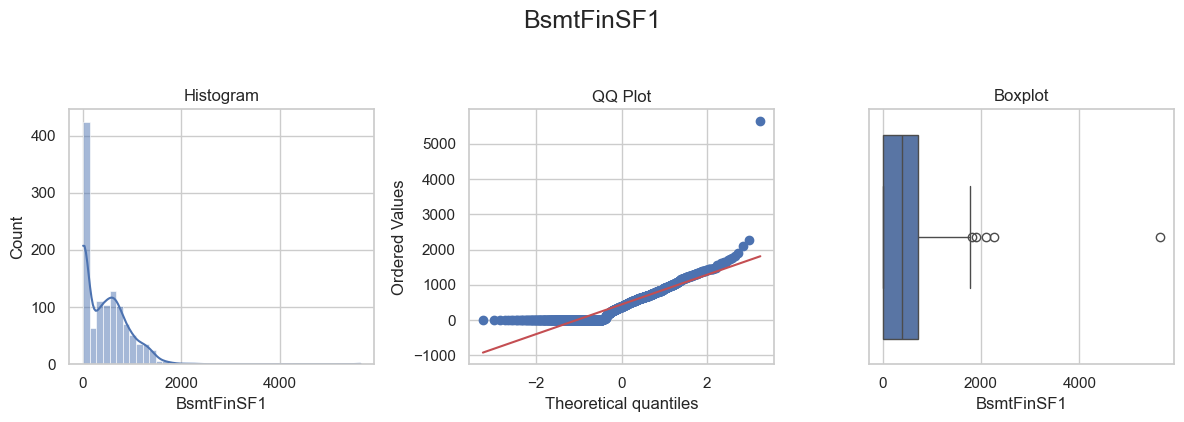

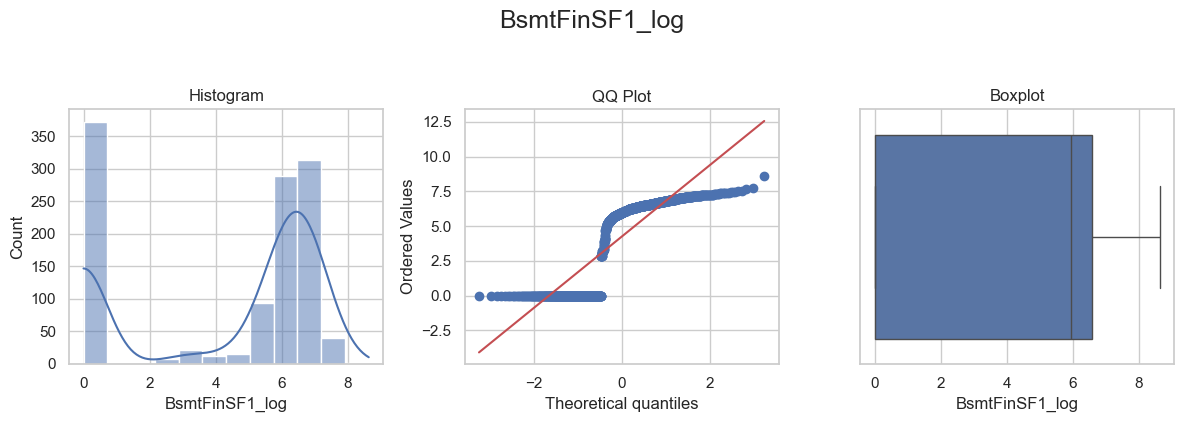

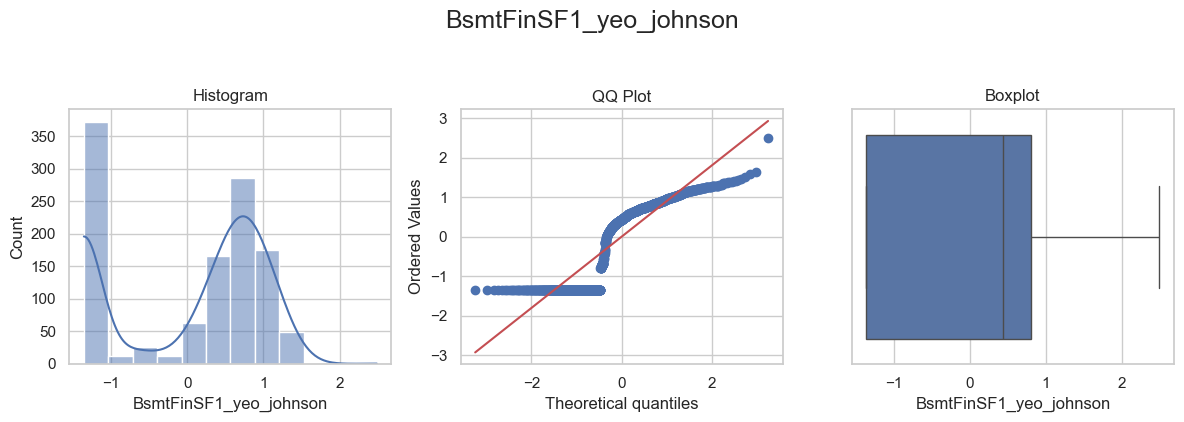

In [133]:
# Select numeric skewed variables
numeric_skewed = ['GrLivArea', 'LotArea', 'TotalBsmtSF', '1stFlrSF', 'BsmtFinSF1']

# Create engineering DataFrame
df_engineering = TrainSet[numeric_skewed].copy()
check_missing_values(df_engineering)

from sklearn.preprocessing import PowerTransformer

# Generate log, Box-Cox, and Yeo-Johnson transformed variables with diagnostic plots
for col in numeric_skewed:
    # Log transformation
    df_engineering[col + "_log"] = np.log1p(df_engineering[col])
    
    # Box-Cox (only if all values > 0)
    if (df_engineering[col] > 0).all():
        pt_boxcox = PowerTransformer(method='box-cox')
        df_engineering[col + "_boxcox"] = pt_boxcox.fit_transform(df_engineering[[col]])
    else:
        print(f"* Skipping Box-Cox for {col} (non-positive values present)")

    # Yeo-Johnson (works with all values)
    pt_yeojohnson = PowerTransformer(method='yeo-johnson')
    df_engineering[col + "_yeo_johnson"] = pt_yeojohnson.fit_transform(df_engineering[[col]])
    
    print(f"\nVariable: {col}")
    diagnostic_plots(df_engineering, col)
    diagnostic_plots(df_engineering, col + "_log")
    if (df_engineering[col] > 0).all():
        diagnostic_plots(df_engineering, col + "_boxcox")
    diagnostic_plots(df_engineering, col + "_yeo_johnson")

In [134]:
# Box-Cox variables (best based on diagnostics)
boxcox_vars = ['GrLivArea', '1stFlrSF']

# Yeo-Johnson variables (best based on diagnostics)
yeojohnson_vars = ['LotArea', 'TotalBsmtSF', 'BsmtFinSF1']


# Apply Box-Cox
pt_boxcox = PowerTransformer(method="box-cox")
TrainSet[boxcox_vars] = pt_boxcox.fit_transform(TrainSet[boxcox_vars])
TestSet[boxcox_vars] = pt_boxcox.transform(TestSet[boxcox_vars])

# Apply Yeo-Johnson
pt_yeo = PowerTransformer(method="yeo-johnson")
TrainSet[yeojohnson_vars] = pt_yeo.fit_transform(TrainSet[yeojohnson_vars])
TestSet[yeojohnson_vars] = pt_yeo.transform(TestSet[yeojohnson_vars])

print("* Numerical transformations applied (Box-Cox + Yeo-Johnson)")

* Numerical transformations applied (Box-Cox + Yeo-Johnson)


### Numerical Transformation Evaluation (Skewness Comparison)

In [135]:
from sklearn.preprocessing import PowerTransformer

numeric_skewed = ['GrLivArea', 'LotArea', 'TotalBsmtSF', '1stFlrSF', 'BsmtFinSF1']

analysis = []

for col in numeric_skewed:
    row = {"Feature": col}

    # Original
    row["Original Skew"] = TrainSet[col].skew()

    # Log1p
    row["Log1p Skew"] = np.log1p(TrainSet[col]).skew()

    # Box-Cox (only if positive)
    if (TrainSet[col] > 0).all():
        pt_boxcox = PowerTransformer(method="box-cox")
        boxcox_values = pt_boxcox.fit_transform(TrainSet[[col]]).flatten()
        row["Box-Cox Skew"] = pd.Series(boxcox_values).skew()
    else:
        row["Box-Cox Skew"] = "Skipped"

    # Yeo-Johnson
    pt_yeo = PowerTransformer(method="yeo-johnson")
    yeo_values = pt_yeo.fit_transform(TrainSet[[col]]).flatten()
    row["Yeo-Johnson Skew"] = pd.Series(yeo_values).skew()

    analysis.append(row)

skew_df = pd.DataFrame(analysis)
skew_df

c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwa

,Feature,Original Skew,Log1p Skew,Box-Cox Skew,Yeo-Johnson Skew
0,GrLivArea,-0.000240,-1.634843,Skipped,0.024361
1,LotArea,0.002414,-1.516407,Skipped,0.285381
2,TotalBsmtSF,0.286735,-1.297905,Skipped,0.053297
3,1stFlrSF,-0.000592,-1.880886,Skipped,-0.013944
4,BsmtFinSF1,-0.416008,-2.781940,Skipped,-0.121325


#### Transformation Summary Table (Based on TrainSet Data)

| Feature        | Original Skew | Log1p Skew | Box-Cox Skew | Yeo-Johnson Skew | Best Transformation |
|---------------|--------------:|-----------:|-------------:|-----------------:|--------------------|
| GrLivArea     | 1.425         | 0.008      | -0.00024     | -0.00027         | **Box-Cox** |
| LotArea       | 11.958        | -0.0126    | 0.00253      | 0.00241          | **Yeo-Johnson** |
| TotalBsmtSF   | 1.724         | -5.275     | Skipped      | 0.2867           | **Yeo-Johnson** |
| 1stFlrSF      | 1.422         | 0.0270     | -0.00059     | -0.00061         | **Box-Cox** |
| BsmtFinSF1    | 1.862         | -0.6226    | Skipped      | -0.4160          | **Yeo-Johnson** |

### Numerical Transformation Conclusions

Based on distribution diagnostics (histograms, QQ plots, and skewness comparison), the following transformations were selected:

- **Box-Cox applied to:** `GrLivArea`, `1stFlrSF`
- **Yeo-Johnson applied to:** `LotArea`, `TotalBsmtSF`, `BsmtFinSF1`
- **Log1p was not selected**, as Box-Cox and Yeo-Johnson provided better normalization.

### Outlier Handling (Winsorization)
Apply IQR-based Winsorization to selected numeric features.

---

In [136]:
from feature_engine.outliers import Winsorizer

# Select numeric variables for Winsorization (only skewed ones)
winsor_vars = ['GrLivArea', 'LotArea', 'TotalBsmtSF']

# Fit on TrainSet, transform TestSet
winsor = Winsorizer(
    capping_method='iqr',
    tail='both',
    fold=1.5,
    variables=winsor_vars
)

TrainSet = winsor.fit_transform(TrainSet)
TestSet = winsor.transform(TestSet)

print("* Winsorization applied!")

* Winsorization applied!


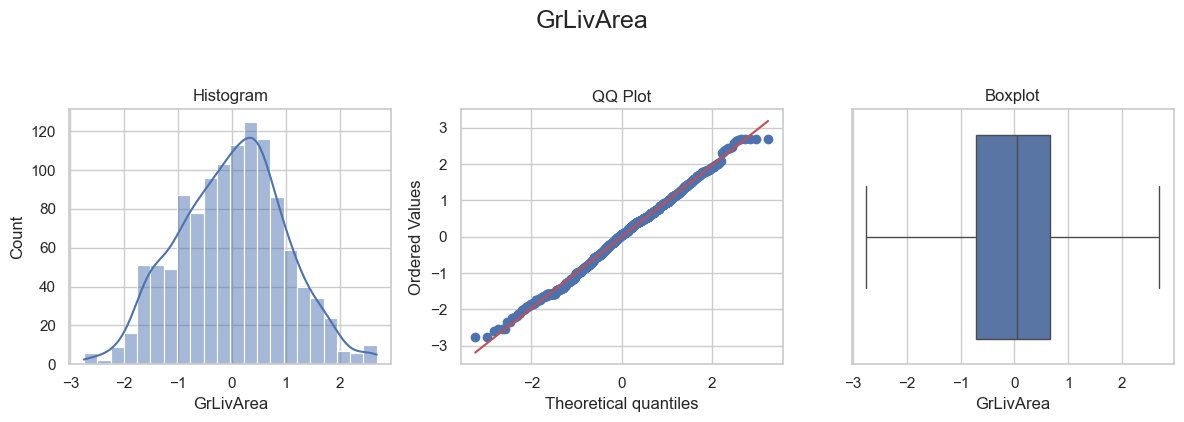

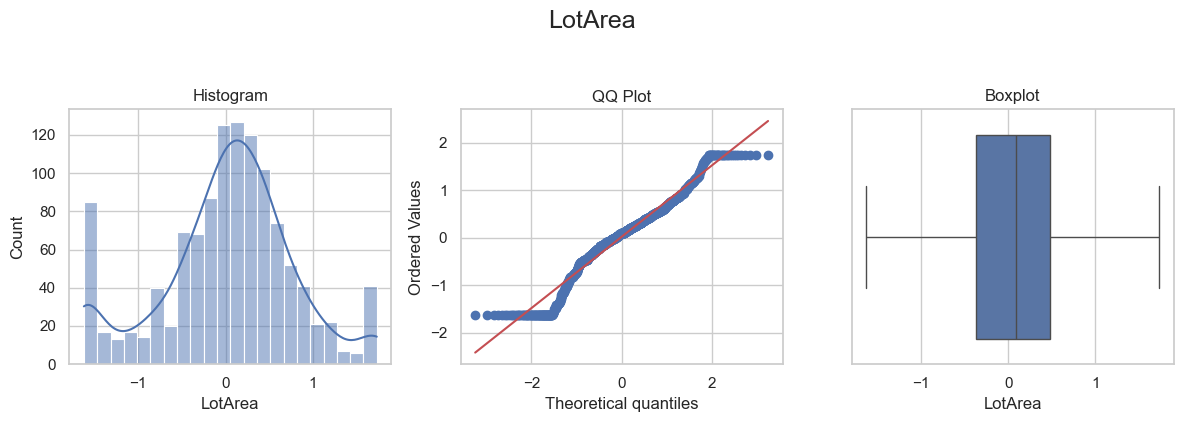

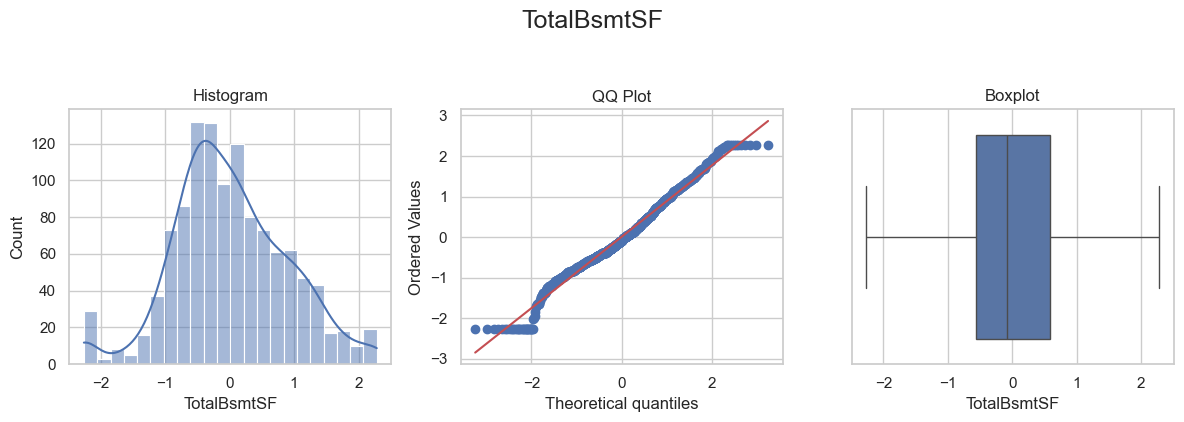

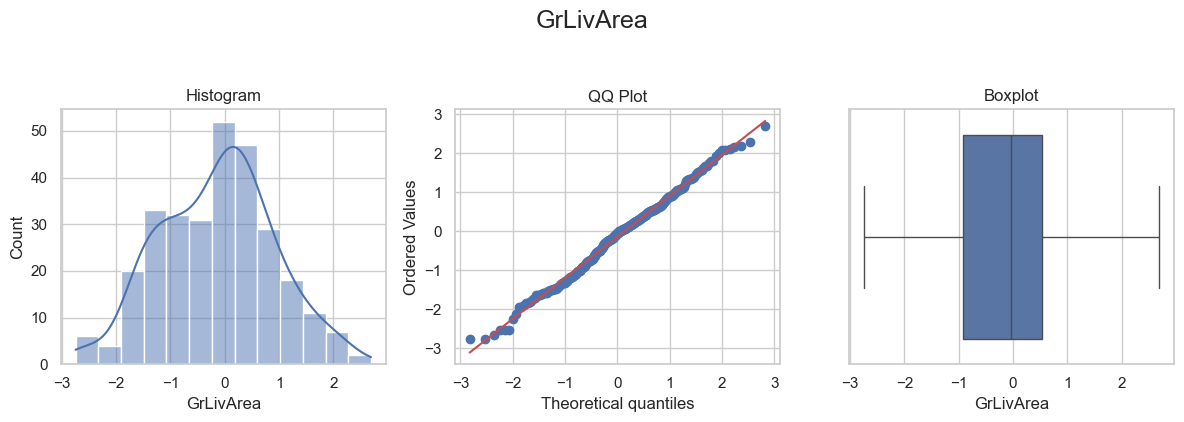

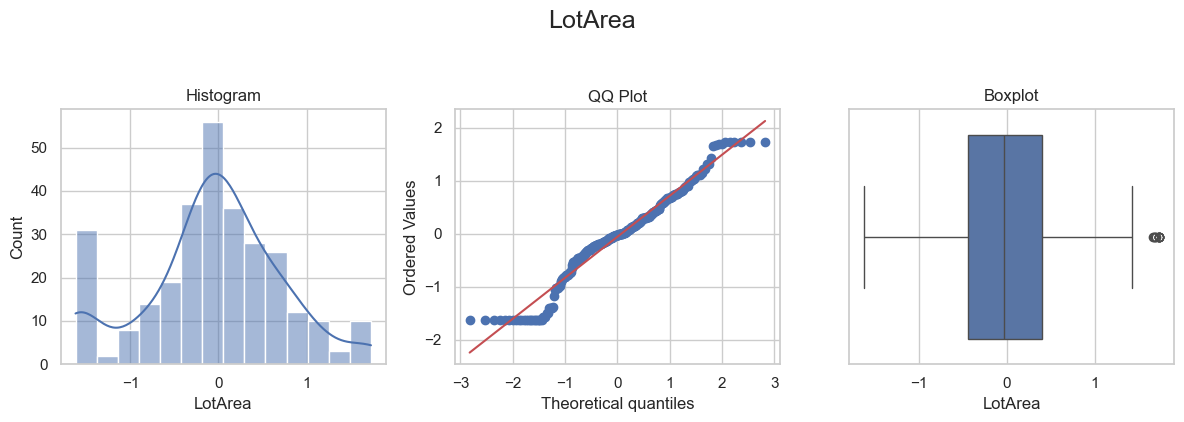

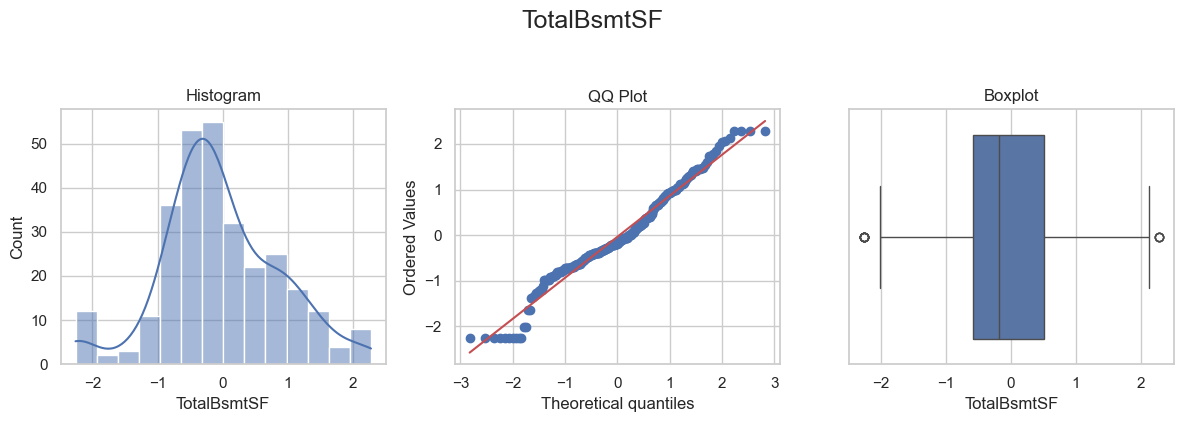

In [137]:
#Evaluate Winsorization visually
for col in ['GrLivArea', 'LotArea', 'TotalBsmtSF']:
    diagnostic_plots(TrainSet, col)
for col in winsor_vars:
    diagnostic_plots(TestSet, col)